# DODA Demonstration
### Decoupled Operator-Driven Architecture

This notebook demonstrates the complete DODA workflow for clinically guided feature selection using the PIMA Diabetes dataset.

## Workflow

Dataset

↓

Operator Integration layer

↓

Clinical knowledge layer

↓

Knowledge Fusion

↓

Core orchestration layer

↓

Pipeline execution

↓

Mathematical Feature Scores

↓

Clinical weights

↓

Final DODA Scores

↓

Feature Ranking

↓

Explainability layer

## Import Libraries

In [8]:
import pandas as pd

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from doda import DODASelector

from doda.adapters import SklearnAdapter

from doda.knowledge.providers import JSONProvider

from doda.fusion import HadamardFusion

## Data Preprocessing

In [9]:
import pandas as pd


def load_dataset(path):

    df = pd.read_csv(path)

    # Separate features and target
    X = df.drop(columns=["Diabetes_binary"])
    y = df["Diabetes_binary"]

    feature_names = X.columns.tolist()

    return X, y, feature_names, df



# Dataset path
DATASET_PATH = "diabetes.csv"


# Execute loader
X, y, feature_names, df = load_dataset(DATASET_PATH)


print("="*60)
print("DATA INGESTION COMPLETE")
print("="*60)

print("Dataset Shape:", df.shape)

print("\nFeature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nNumber of Features:", len(feature_names))

print("\nFeature Names:")
for i, col in enumerate(feature_names, 1):
    print(f"{i}. {col}")

DATA INGESTION COMPLETE
Dataset Shape: (253680, 22)

Feature Matrix Shape: (253680, 21)
Target Shape: (253680,)

Number of Features: 21

Feature Names:
1. HighBP
2. HighChol
3. CholCheck
4. BMI
5. Smoker
6. Stroke
7. HeartDiseaseorAttack
8. PhysActivity
9. Fruits
10. Veggies
11. HvyAlcoholConsump
12. AnyHealthcare
13. NoDocbcCost
14. GenHlth
15. MentHlth
16. PhysHlth
17. DiffWalk
18. Sex
19. Age
20. Education
21. Income


In [10]:
def data_quality_audit(X, y):

    audit = {}

    # Missing values
    audit["missing_values"] = X.isnull().sum()

    # Duplicate rows
    audit["duplicates"] = X.duplicated().sum()

    # Datatypes
    audit["data_types"] = X.dtypes

    # Class distribution
    audit["class_distribution"] = y.value_counts()

    # Feature statistics
    audit["summary_statistics"] = X.describe().T


    return audit



audit_report = data_quality_audit(X, y)


print("="*60)
print("DATA QUALITY AUDIT")
print("="*60)


print("\nMissing Values:")
display(audit_report["missing_values"])


print("\nDuplicate Records:")
print(audit_report["duplicates"])


print("\nData Types:")
display(audit_report["data_types"])


print("\nTarget Distribution:")
display(audit_report["class_distribution"])


print("\nFeature Statistics:")
display(audit_report["summary_statistics"])

DATA QUALITY AUDIT

Missing Values:


HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


Duplicate Records:
25772

Data Types:


HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object


Target Distribution:


Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64


Feature Statistics:


,count,mean,std,min,25%,50%,75%,max
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0
Veggies,253680.0,0.811420,0.391175,0.0,1.0,1.0,1.0,1.0


In [11]:
# ============================================================
# DUPLICATE RESOLUTION OPERATOR
# ============================================================

def remove_duplicates(df, target_col="Diabetes_binary"):
    original_size = len(df)
    
    # Isolate features to find exact feature-profile duplicates
    feature_cols = [col for col in df.columns if col != target_col]
    
    # Identify duplicates based strictly on feature criteria
    duplicate_count = df.duplicated(subset=feature_cols).sum()
    
    # Drop rows based on feature duplication, keeping the first occurrence
    df_clean = (
        df
        .drop_duplicates(subset=feature_cols, keep="first")
        .reset_index(drop=True)
    )
    
    removed_percentage = (duplicate_count / original_size) * 100
    
    duplicate_report = {
        "original_records": original_size,
        "duplicate_records": duplicate_count,
        "remaining_records": len(df_clean),
        "removed_percentage": removed_percentage
    }
    
    return df_clean, duplicate_report

# Execute duplicate operator correctly
df_clean, duplicate_report = remove_duplicates(df)


print("="*60)
print("DUPLICATE RESOLUTION COMPLETE")
print("="*60)

for key, value in duplicate_report.items():
    print(f"{key}: {value}")

DUPLICATE RESOLUTION COMPLETE
original_records: 253680
duplicate_records: 25772
remaining_records: 227908
removed_percentage: 10.159255755282246


In [12]:
# ============================================================
# FEATURE MATRIX RECONSTRUCTION
# ============================================================


X = df_clean.drop(
    columns=["Diabetes_binary"]
)

y = df_clean["Diabetes_binary"]


feature_names = X.columns.tolist()



print("="*60)
print("FEATURE MATRIX UPDATED")
print("="*60)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

FEATURE MATRIX UPDATED
X Shape: (227908, 21)
y Shape: (227908,)

Target Distribution:
Diabetes_binary
0.0    193729
1.0     34179
Name: count, dtype: int64


In [13]:
# ============================================================
# ROBUST SCALING OPERATOR
# ============================================================

from sklearn.preprocessing import RobustScaler


def robust_scale_features(X):

    scaler = RobustScaler()

    X_scaled = scaler.fit_transform(X)

    X_scaled = pd.DataFrame(
        X_scaled,
        columns=X.columns
    )

    return X_scaled, scaler



X_scaled, scaler = robust_scale_features(X)



print("="*60)
print("SCALING COMPLETE")
print("="*60)

print("Scaled Matrix Shape:", X_scaled.shape)

display(X_scaled.head())

SCALING COMPLETE
Scaled Matrix Shape: (227908, 21)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1.0,1.0,0.0,1.625,1.0,0.0,0.0,-1.0,-1.0,0.0,...,0.0,0.0,2.0,9.0,3.75,1.0,0.0,0.25,-0.5,-0.75
1,0.0,0.0,-1.0,-0.250,1.0,0.0,0.0,0.0,-1.0,-1.0,...,-1.0,1.0,0.0,0.0,0.00,0.0,0.0,-0.25,0.5,-1.25
2,1.0,1.0,0.0,0.125,0.0,0.0,0.0,-1.0,0.0,-1.0,...,0.0,1.0,2.0,15.0,7.50,1.0,0.0,0.25,-0.5,0.50
3,1.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-1.0,0.0,0.00,0.0,0.0,0.75,-1.0,0.00
4,1.0,1.0,0.0,-0.375,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-1.0,1.5,0.00,0.0,0.0,0.75,0.0,-0.50


In [14]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


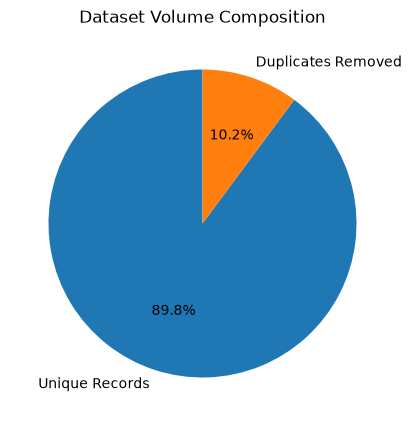

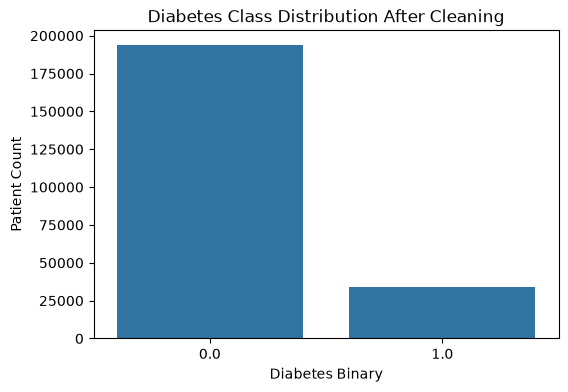

In [15]:
# ============================================================
# PREPROCESSING AUDIT VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns


# -------------------------------
# Panel A: Duplicate Composition
# -------------------------------

original_records = duplicate_report["original_records"]

duplicates_removed = duplicate_report["duplicate_records"]

unique_records = duplicate_report["remaining_records"]


plt.figure(figsize=(6,5))


plt.pie(
    [
        unique_records,
        duplicates_removed
    ],
    labels=[
        "Unique Records",
        "Duplicates Removed"
    ],
    autopct="%1.1f%%",
    startangle=90
)


plt.title(
    "Dataset Volume Composition"
)

plt.show()



# -------------------------------
# Panel B: Target Distribution
# -------------------------------


plt.figure(figsize=(6,4))


sns.countplot(
    x=y
)


plt.title(
    "Diabetes Class Distribution After Cleaning"
)

plt.xlabel(
    "Diabetes Binary"
)

plt.ylabel(
    "Patient Count"
)


plt.show()

## Train/Test split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

## Standardization

In [17]:
scaler = StandardScaler()

X_train = pd.DataFrame(

    scaler.fit_transform(X_train),

    columns=X.columns

)

X_test = pd.DataFrame(

    scaler.transform(X_test),

    columns=X.columns

)

# DODA

## Operation Integration Layer

ANOVA is wrapped using the SklearnAdapter, allowing DODA to integrate external feature selection methods through a common interface.

In [18]:
anova = SklearnAdapter(

    SelectKBest(

        score_func=f_classif,

        k="all"

    )

)

### Explanation

The Operator Integration Layer is responsible for connecting external feature selection algorithms to the DODA framework through a standardized interface.

Rather than implementing its own mathematical feature selector, DODA treats every feature selection algorithm as an independent operator. The SklearnAdapter wraps any scikit-learn compatible feature selector and converts its output into a common feature-score representation that DODA can understand.

This design allows users to replace ANOVA with LASSO, Random Forest, mRMR, or any future algorithm without modifying the framework itself.

DODA adds:

A common interface for all mathematical operators.
Zero dependency on a specific feature selection algorithm.
Plug-and-play extensibility.

## Clinical Knowledge Layer

Clinical relevance weights are loaded from an external JSON knowledge source.

In [19]:
provider = JSONProvider(

    "clinical_weights.json"

)

### Explanation

The Clinical Knowledge Layer injects domain-specific knowledge into the feature selection process.

The JSONProvider retrieves predefined clinical relevance weights for every feature from an external knowledge source. These weights represent expert knowledge regarding the medical importance of individual clinical variables.

Although this demonstration uses a JSON file, the provider architecture is designed to support alternative knowledge sources such as REST APIs, FHIR servers, clinical databases, ontologies, or knowledge graphs without requiring changes to the DODA pipeline.

DODA adds:

Separation of clinical knowledge from mathematical computation.
Swappable knowledge sources.
Domain-aware feature evaluation.

## Knowledge Fusion Layer

Mathematical scores are fused with clinical relevance weights using Hadamard multiplication.

In [20]:
fusion = HadamardFusion()

### Explanation

The Knowledge Fusion Layer combines mathematical feature importance with clinical relevance.

The HadamardFusion module performs element-wise multiplication between the normalized mathematical scores and the corresponding clinical weights.

FinalScore=MathematicalScore×ClinicalWeight

This operation adjusts feature importance according to domain knowledge while preserving the original statistical evidence.

DODA adds:

Integration of data-driven and expert-driven evidence.
Clinically guided feature prioritization.
Modular fusion strategies (other fusion methods could be added later).

## Core Layer

In [21]:
selector = DODASelector(

    operators=[anova],

    provider=provider,

    fusion=fusion,

    top_k=5

)

### Explanation

The Core Orchestration Layer coordinates the execution of all independent DODA modules.

DODASelector serves as the primary interface exposed to end users. It sequentially invokes the operator layer to compute mathematical scores, retrieves clinical weights from the knowledge layer, applies the selected fusion strategy, ranks the resulting feature scores, and returns the final clinically guided feature subset.

By encapsulating the complete workflow behind a single interface, the framework remains modular while simplifying usage.

DODA adds:

Centralized workflow management.
Decoupled communication between layers.
Scikit-learn compatible API.

## DODA Pipeline Execution

In [22]:
X_train_selected = selector.fit_transform(

    X_train,

    y_train

)

Provider inside knowledge engine: <doda.knowledge.providers.json_provider.JSONProvider object at 0x000001C99A05DD10>
DODA Pipeline Started
Running: SelectKBest
Operator Scores:
{'SelectKBest_1': {'HighBP': np.float64(12848.036402158592), 'HighChol': np.float64(7239.375615440028), 'CholCheck': np.float64(927.6105497433493), 'BMI': np.float64(8385.88089007888), 'Smoker': np.float64(438.38703474408084), 'Stroke': np.float64(1942.4629722338454), 'HeartDiseaseorAttack': np.float64(5577.1781772487175), 'PhysActivity': np.float64(2049.3433387795094), 'Fruits': np.float64(137.45258075165077), 'Veggies': np.float64(388.57896768483624), 'HvyAlcoholConsump': np.float64(771.2431576011215), 'AnyHealthcare': np.float64(98.67608154834522), 'NoDocbcCost': np.float64(83.65751213743683), 'GenHlth': np.float64(15841.729869265002), 'MentHlth': np.float64(624.6313328699698), 'PhysHlth': np.float64(5002.686017585408), 'DiffWalk': np.float64(8563.326312661246), 'Sex': np.float64(169.88707547913555), 'Age': n

### Explanation

The fit_transform() method executes the complete DODA pipeline.

Internally, DODA performs the following sequence:

Executes the selected mathematical operator.
Computes normalized feature importance scores.
Retrieves clinical relevance weights.
Applies knowledge fusion.
Ranks all features according to their fused scores.
Returns the Top-K clinically guided feature subset.

This allows the user to perform the entire clinically guided feature selection workflow with a single function call.

In [23]:
X_test_selected = selector.transform(

    X_test

)

## Mathematical scores

In [24]:
math_scores = pd.DataFrame(

    selector.get_math_scores().items(),

    columns=[

        "Feature",

        "Math Score"

    ]

)

math_scores.sort_values(

    by="Math Score",

    ascending=False

)

,Feature,Math Score
13,GenHlth,15841.729869
0,HighBP,12848.036402
16,DiffWalk,8563.326313
3,BMI,8385.880890
1,HighChol,7239.375615
18,Age,5838.101123
6,HeartDiseaseorAttack,5577.178177
15,PhysHlth,5002.686018
20,Income,4029.921302
19,Education,2144.465338


### Explanation

This method returns the normalized mathematical importance scores generated directly by the feature selection operator before any clinical information is incorporated.

These scores represent the purely data-driven assessment of feature importance.

Purpose

Provides the baseline against which clinically guided rankings can be compared.

## Clinical weights

In [25]:
clinical_weights = pd.DataFrame(

    selector.get_clinical_weights().items(),

    columns=[

        "Feature",

        "Clinical Weight"

    ]

)

clinical_weights

,Feature,Clinical Weight
0,HighBP,1.0
1,HighChol,0.9
2,CholCheck,0.4
3,BMI,1.0
4,Smoker,0.6
5,Stroke,1.0
6,HeartDiseaseorAttack,1.0
7,PhysActivity,0.4
8,Fruits,0.2
9,Veggies,0.2


### Explanation

This method returns the clinical relevance weights retrieved from the external knowledge provider.

Each weight quantifies the domain-specific importance assigned to an individual clinical variable.

Purpose

Makes the external knowledge used by DODA fully transparent and explainable.

## Final DODA Scores

In [26]:
final_scores = pd.DataFrame(

    selector.get_final_scores().items(),

    columns=[

        "Feature",

        "Final Score"

    ]

)

final_scores.sort_values(

    by="Final Score",

    ascending=False

)

,Feature,Final Score
13,GenHlth,15841.729869
0,HighBP,12848.036402
3,BMI,8385.880890
16,DiffWalk,7706.993681
1,HighChol,6515.438054
6,HeartDiseaseorAttack,5577.178177
18,Age,5254.291011
15,PhysHlth,4002.148814
5,Stroke,1942.462972
20,Income,1208.976391


### Explanation

This method returns the fused feature scores after combining mathematical importance with clinical relevance.

These scores represent the final importance values used by DODA for feature ranking and selection.

Purpose

Produces clinically guided feature importance instead of relying solely on statistical evidence.

## Ranking Layer

In [27]:
selector.get_selected_features()

['GenHlth', 'HighBP', 'BMI', 'DiffWalk', 'HighChol']

### Explanation

The Decision Layer ranks all fused feature scores and selects the highest-ranked Top-K features.

The ranking process is independent of the mathematical operator and depends only on the final DODA scores.

DODA adds:

Consistent feature selection regardless of the underlying operator.
Configurable Top-K selection strategy.

## Explainability Layer

In [28]:
comparison = selector.compare_scores()

comparison

,Feature,Math Rank,Math Score,Clinical Weight,DODA Rank,Final Score,Rank Change
0,GenHlth,1,15841.7299,1.0,1,15841.7299,0
1,HighBP,2,12848.0364,1.0,2,12848.0364,0
2,BMI,4,8385.8809,1.0,3,8385.8809,1
3,DiffWalk,3,8563.3263,0.9,4,7706.9937,-1
4,HighChol,5,7239.3756,0.9,5,6515.4381,0
5,HeartDiseaseorAttack,7,5577.1782,1.0,6,5577.1782,1
6,Age,6,5838.1011,0.9,7,5254.2910,-1
7,PhysHlth,8,5002.6860,0.8,8,4002.1488,0
8,Stroke,12,1942.4630,1.0,9,1942.4630,3
9,Income,9,4029.9213,0.3,10,1208.9764,-1


### Explanation

The comparison report summarizes the complete decision-making process of DODA.

For every feature, it reports:

Mathematical rank
Mathematical score
Clinical relevance weight
Final DODA rank
Final DODA score
Rank change after clinical fusion

This comparison makes the influence of clinical knowledge fully interpretable by illustrating how domain expertise modifies purely statistical feature rankings.

DODA adds:

Transparent decision tracing.
Quantification of the impact of clinical knowledge.
Explainable feature prioritization suitable for healthcare applications.

## Training vs Test data

In [29]:
X_train_selected.head()

,GenHlth,HighBP,BMI,DiffWalk,HighChol
0,1.306537,-0.910123,0.930283,-0.479916,-0.887358
1,1.306537,1.098752,0.782975,-0.479916,1.126941
2,-0.565985,1.098752,0.193745,-0.479916,1.126941
3,0.370276,1.098752,0.341052,-0.479916,-0.887358
4,0.370276,-0.910123,-0.248178,-0.479916,-0.887358


In [30]:
X_test_selected.head()

,GenHlth,HighBP,BMI,DiffWalk,HighChol
0,0.370276,1.098752,-0.248178,-0.479916,-0.887358
1,-1.502246,1.098752,-1.426639,-0.479916,-0.887358
2,-0.565985,-0.910123,0.635667,-0.479916,-0.887358
3,0.370276,1.098752,0.488360,2.083696,1.126941
4,0.370276,-0.910123,-0.690101,-0.479916,-0.887358


In [31]:
print("Original Features :", X_train.shape[1])

print("Selected Features :", X_train_selected.shape[1])

print()

print("Selected Feature Names:")

print(selector.get_selected_features())

Original Features : 21
Selected Features : 5

Selected Feature Names:
['GenHlth', 'HighBP', 'BMI', 'DiffWalk', 'HighChol']


# MULTIPLE FS METHODS

In [32]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    mutual_info_classif,
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from doda import DODASelector

from doda.adapters import SklearnAdapter

from doda.aggregation import MeanAggregator

from doda.knowledge.providers import JSONProvider

from doda.fusion import HadamardFusion

### Create Operators

In [33]:
anova = SklearnAdapter(

    SelectKBest(

        score_func=f_classif,

        k="all"

    )

)


mi = SklearnAdapter(

    SelectKBest(

        score_func=mutual_info_classif,

        k="all"

    )

)


rf = SklearnAdapter(

    RandomForestClassifier(

        n_estimators=300,

        random_state=42

    )

)


lasso = SklearnAdapter(

    LogisticRegression(

        penalty="l1",

        solver="liblinear",

        random_state=42

    )

)

### Aggregator

In [34]:
aggregator = MeanAggregator()

### Knowledge provider

In [35]:
provider = JSONProvider(

    "clinical_weights.json"

)

### Fusion

In [36]:
fusion = HadamardFusion()

### DODA

In [37]:
selector = DODASelector(

    operators=[

        anova,

        mi,

        rf,

        lasso

    ],

    aggregator=aggregator,

    provider=provider,

    fusion=fusion,

    top_k=5

)

### Execution

In [39]:
X_train_selected = selector.fit_transform(

    X_train,

    y_train

)

Provider inside knowledge engine: <doda.knowledge.providers.json_provider.JSONProvider object at 0x000001C99A05E710>
DODA Pipeline Started
Running: SelectKBest
Running: SelectKBest
Running: RandomForestClassifier
Running: LogisticRegression


c:\Users\Anandha Lakshmi\doda\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Anandha Lakshmi\doda\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Operator Scores:
{'SelectKBest_1': {'HighBP': np.float64(12848.036402158592), 'HighChol': np.float64(7239.375615440028), 'CholCheck': np.float64(927.6105497433493), 'BMI': np.float64(8385.88089007888), 'Smoker': np.float64(438.38703474408084), 'Stroke': np.float64(1942.4629722338454), 'HeartDiseaseorAttack': np.float64(5577.1781772487175), 'PhysActivity': np.float64(2049.3433387795094), 'Fruits': np.float64(137.45258075165077), 'Veggies': np.float64(388.57896768483624), 'HvyAlcoholConsump': np.float64(771.2431576011215), 'AnyHealthcare': np.float64(98.67608154834522), 'NoDocbcCost': np.float64(83.65751213743683), 'GenHlth': np.float64(15841.729869265002), 'MentHlth': np.float64(624.6313328699698), 'PhysHlth': np.float64(5002.686017585408), 'DiffWalk': np.float64(8563.326312661246), 'Sex': np.float64(169.88707547913555), 'Age': np.float64(5838.101123033708), 'Education': np.float64(2144.4653383684113), 'Income': np.float64(4029.9213021096384)}, 'SelectKBest_2': {'HighBP': np.float64(0.0

In [40]:
selector.get_math_scores()

{'HighBP': np.float64(3212.125418291),
 'HighChol': np.float64(1809.9299540270472),
 'CholCheck': np.float64(231.96575033684667),
 'BMI': np.float64(2096.6249223894742),
 'Smoker': np.float64(109.61092720941562),
 'Stroke': np.float64(485.628661801527),
 'HeartDiseaseorAttack': np.float64(1394.3218073250994),
 'PhysActivity': np.float64(512.3526064304729),
 'Fruits': np.float64(34.38049234392808),
 'Veggies': np.float64(97.15870463867346),
 'HvyAlcoholConsump': np.float64(192.8633438103313),
 'AnyHealthcare': np.float64(24.677146860440487),
 'NoDocbcCost': np.float64(20.921226896716203),
 'GenHlth': np.float64(3960.5984022410007),
 'MentHlth': np.float64(156.1838187295496),
 'PhysHlth': np.float64(1250.7128422564708),
 'DiffWalk': np.float64(2140.858092004931),
 'Sex': np.float64(42.5134742857564),
 'Age': np.float64(1459.6543451980224),
 'Education': np.float64(536.1445435364576),
 'Income': np.float64(1007.5345942642201)}

In [41]:
selector.get_clinical_weights()

{'HighBP': 1.0,
 'HighChol': 0.9,
 'CholCheck': 0.4,
 'BMI': 1.0,
 'Smoker': 0.6,
 'Stroke': 1.0,
 'HeartDiseaseorAttack': 1.0,
 'PhysActivity': 0.4,
 'Fruits': 0.2,
 'Veggies': 0.2,
 'HvyAlcoholConsump': 0.2,
 'AnyHealthcare': 0.2,
 'NoDocbcCost': 0.2,
 'GenHlth': 1.0,
 'MentHlth': 0.5,
 'PhysHlth': 0.8,
 'DiffWalk': 0.9,
 'Sex': 0.2,
 'Age': 0.9,
 'Education': 0.3,
 'Income': 0.3}

In [42]:
selector.get_final_scores()

{'HighBP': np.float64(3212.125418291),
 'HighChol': np.float64(1628.9369586243424),
 'CholCheck': np.float64(92.78630013473867),
 'BMI': np.float64(2096.6249223894742),
 'Smoker': np.float64(65.76655632564938),
 'Stroke': np.float64(485.628661801527),
 'HeartDiseaseorAttack': np.float64(1394.3218073250994),
 'PhysActivity': np.float64(204.94104257218916),
 'Fruits': np.float64(6.876098468785617),
 'Veggies': np.float64(19.431740927734694),
 'HvyAlcoholConsump': np.float64(38.57266876206626),
 'AnyHealthcare': np.float64(4.935429372088098),
 'NoDocbcCost': np.float64(4.184245379343241),
 'GenHlth': np.float64(3960.5984022410007),
 'MentHlth': np.float64(78.0919093647748),
 'PhysHlth': np.float64(1000.5702738051767),
 'DiffWalk': np.float64(1926.7722828044382),
 'Sex': np.float64(8.502694857151281),
 'Age': np.float64(1313.6889106782203),
 'Education': np.float64(160.84336306093726),
 'Income': np.float64(302.26037827926604)}

In [43]:
selector.compare_scores()

,Feature,Math Rank,Math Score,Clinical Weight,DODA Rank,Final Score,Rank Change
0,GenHlth,1,3960.5984,1.0,1,3960.5984,0
1,HighBP,2,3212.1254,1.0,2,3212.1254,0
2,BMI,4,2096.6249,1.0,3,2096.6249,1
3,DiffWalk,3,2140.8581,0.9,4,1926.7723,-1
4,HighChol,5,1809.9300,0.9,5,1628.9370,0
5,HeartDiseaseorAttack,7,1394.3218,1.0,6,1394.3218,1
6,Age,6,1459.6543,0.9,7,1313.6889,-1
7,PhysHlth,8,1250.7128,0.8,8,1000.5703,0
8,Stroke,12,485.6287,1.0,9,485.6287,3
9,Income,9,1007.5346,0.3,10,302.2604,-1


In [44]:
selector.get_selected_features()

['GenHlth', 'HighBP', 'BMI', 'DiffWalk', 'HighChol']